# 600: prepare full df, overview Scenario Group Analysis

This notebook calculates the probability that warming declines after net-zero emissions are achieved,
comparing four groups of scenarios:
1. **Scenarios (NZCO2)**: Scenarios with "NZCO2" in the label
2. **Scenarios (NZGHG)**: Scenarios with "NZKyoto" in the label
3. **Stylised Variants (NZCO2-hold")**
4. **Stylised Variants (NZGHG-hold")**


**Criteria for decline:**
- Delta warming (NZCO2 - 2100) > 0°C

In [2]:
import os
from pathlib import Path

import dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dotenv.load_dotenv()

True

In [3]:
# Configuration
OUTPUT_FOLDER = Path(os.environ["OUTPUT_FOLDER"])
PLOT_FOLDER = OUTPUT_FOLDER / "plots"
PLOT_FOLDER.mkdir(parents=True, exist_ok=True)

# Guardrails for classifying decline
PEAK_YEAR_THRESHOLD = 2100  # Peak must occur before this year
DELTA_WARMING_THRESHOLD = 0.0  # Minimum decline in °C to count as decline

In [4]:
# Input metrics file - uses combined manifest from 401
MANIFEST_ID = "regenerated"
#METRICS_FILE = OUTPUT_FOLDER / f"500_gsat_metrics_{MANIFEST_ID}.csv"
METRICS_FILE = OUTPUT_FOLDER / f"500b_component_metrics_{MANIFEST_ID}.csv"

## Load and Filter Data

In [118]:
# Load 500b component metrics
all_df = pd.read_csv(OUTPUT_FOLDER / METRICS_FILE)
# Filter to rows where net-zero CO2 year extraction was possible
all_df = all_df[all_df["GSAT|ANTHROPOGENIC|netzero_co2"].notna()].copy()
print(f"Rows with valid NZCO2-year extraction: {len(all_df)}")

# Classify scenarios into groups
all_df["scenario_group"] = all_df["scenario"].apply(
    lambda x: "Stylised Variants (NZCO2-hold)" if "NZCO2" in x
    else ("Stylised Variants (NZGHG-hold)" if "NZKyoto" in x else "Scenarios (NZCO2)")
)

# Build set of (model, stripped_scenario) keys from NZKyoto
nzkyoto_combos = set(
    all_df[all_df["scenario_group"] == "Stylised Variants (NZGHG-hold)"]
    .assign(scenario_key=lambda d: d["scenario"].str.replace("_NZKyoto", "", regex=False))
    [["model", "scenario_key"]]
    .itertuples(index=False, name=None)
)

# Find Base rows whose (model, scenario) pair matches a stripped NZKyoto combo
base_df = all_df[all_df["scenario_group"] == "Scenarios (NZCO2)"]
mask = base_df.apply(
    lambda r: (r["model"], r["scenario"]) in nzkyoto_combos, axis=1
)
base_nzghg = base_df[mask].copy()
base_nzghg["scenario_group"] = "Scenarios (NZGHG)"

# Scenarios (NZCO2) that are NOT in NZGHG
base_nzco2_only = base_df[~mask.values].copy()
base_nzco2_only["scenario_group"] = "Scenarios (NZCO2, no NZGHG)"

# Find Stylised Variants (NZCO2-hold) whose base scenario is NOT in NZGHG combos
sv_nzco2_df = all_df[all_df["scenario_group"] == "Stylised Variants (NZCO2-hold)"]
mask_sv = sv_nzco2_df.apply(
    lambda r: (r["model"], r["scenario"].replace("_NZCO2", "")) in nzkyoto_combos, axis=1
)
sv_nzco2_only = sv_nzco2_df[~mask_sv].copy()
sv_nzco2_only["scenario_group"] = "Stylised Variants (NZCO2-hold, no NZGHG)"

# Concatenate without overwriting all_df
all_df_extended = pd.concat(
    [all_df, base_nzghg, base_nzco2_only, sv_nzco2_only],
    ignore_index=True
)

# Show group counts
group_counts = (
    all_df_extended
    .drop_duplicates(subset=["model", "scenario", "scenario_group"])
    .groupby("scenario_group")
    .agg(
        n_rows=("run_id", "count"),
        n_unique_model_scenarios=("scenario", "count")
    )
)
print("\nScenario group summary:")
group_counts

Rows with valid NZCO2-year extraction: 1018800

Scenario group summary:


,n_rows,n_unique_model_scenarios
scenario_group,,
Scenarios (NZCO2),685,685
"Scenarios (NZCO2, no NZGHG)",357,357
Scenarios (NZGHG),328,328
Stylised Variants (NZCO2-hold),685,685
"Stylised Variants (NZCO2-hold, no NZGHG)",357,357
Stylised Variants (NZGHG-hold),328,328


## Classify Ensemble Members

In [119]:
all_df_extended["GSAT|ANTHROPOGENIC|delta_netzero_co2"] = all_df_extended["GSAT|ANTHROPOGENIC|2100"] - all_df_extended["GSAT|ANTHROPOGENIC|netzero_co2"]
all_df_extended["GSAT|ANTHROPOGENIC|delta_peak_gsat"] = all_df_extended["GSAT|ANTHROPOGENIC|2100"] - all_df_extended["GSAT|ANTHROPOGENIC|peak"]

In [120]:
# Apply guardrails to classify each ensemble member as "decline" or not
all_df_extended["is_decline"] = (
    (all_df_extended["peak_year"] < PEAK_YEAR_THRESHOLD) &
    (all_df_extended["GSAT|ANTHROPOGENIC|delta_netzero_co2"] < DELTA_WARMING_THRESHOLD)
)

# Summary by group
decline_summary = all_df_extended.groupby("scenario_group").agg(
    total_members=("is_decline", "count"),
    decline_members=("is_decline", "sum"),
)
decline_summary["no_decline_members"] = decline_summary["total_members"] - decline_summary["decline_members"]
decline_summary["pct_decline"] = (decline_summary["decline_members"] / decline_summary["total_members"] * 100).round(1)
print("Decline classification by scenario group 2100 - NZCO2 year:")
decline_summary

Decline classification by scenario group 2100 - NZCO2 year:


,total_members,decline_members,no_decline_members,pct_decline
scenario_group,,,,
Scenarios (NZCO2),411000,344961,66039,83.9
"Scenarios (NZCO2, no NZGHG)",214200,162642,51558,75.9
Scenarios (NZGHG),196800,182319,14481,92.6
Stylised Variants (NZCO2-hold),411000,294100,116900,71.6
"Stylised Variants (NZCO2-hold, no NZGHG)",214200,144081,70119,67.3
Stylised Variants (NZGHG-hold),196800,177421,19379,90.2


this is for peak temp instead of NZCO2

# Apply guardrails to classify each ensemble member as "decline" or not
all_df_extended_gsat = all_df_extended.copy()

all_df_extended_gsat["is_decline"] = (
    (all_df_extended_gsat["peak_year"] < PEAK_YEAR_THRESHOLD) &
    (all_df_extended_gsat["GSAT|ANTHROPOGENIC|delta_peak_gsat"] < DELTA_WARMING_THRESHOLD)
)

# Summary by group
decline_summary_gsat = all_df_extended_gsat.groupby("scenario_group").agg(
    total_members=("is_decline", "count"),
    decline_members=("is_decline", "sum"),
)
decline_summary_gsat["no_decline_members"] = decline_summary_gsat["total_members"] - decline_summary_gsat["decline_members"]
decline_summary_gsat["pct_decline"] = (decline_summary_gsat["decline_members"] / decline_summary_gsat["total_members"] * 100).round(1)
print("Decline classification by scenario group 2100 - peak GSAT year:")
decline_summary_gsat

## Table 1 Probability of GSAT decline from NZCO2 year

In [121]:
rename_map = {
    "Scenarios (NZCO2)": "Scenarios\n(NZCO2)",
    "Scenarios (NZCO2, no NZGHG)": "Scenarios\n(NZCO2, no NZGHG)",
    "Scenarios (NZGHG)": "Scenarios\n(NZGHG)",
    "Stylised Variants (NZCO2-hold)": "Stylised Variants\n(NZCO2-hold)",
    "Stylised Variants (NZCO2-hold, no NZGHG)": "Stylised Variants\n(NZCO2-hold, no NZGHG)",
    "Stylised Variants (NZGHG-hold)": "Stylised Variants\n(NZGHG-hold)",
}

In [122]:
# Group by model, scenario, and scenario_group, calculate probability
decline_prob = all_df_extended.groupby(["scenario_group", "model", "scenario"]).agg(
    n_ensemble=pd.NamedAgg(column="run_id", aggfunc="count"),
    n_decline=pd.NamedAgg(column="is_decline", aggfunc="sum"),
).reset_index()

# Calculate probability
decline_prob["prob_decline"] = decline_prob["n_decline"] / decline_prob["n_ensemble"]
decline_prob["prob_decline_pct"] = (decline_prob["prob_decline"] * 100).round(1)

print(f"Calculated probabilities for {len(decline_prob)} scenarios")
decline_prob.head(10)

Calculated probabilities for 2740 scenarios


,scenario_group,model,scenario,n_ensemble,n_decline,prob_decline,prob_decline_pct
0,Scenarios (NZCO2),AIM/CGE 2.0,SSP1-19,600,588,0.980000,98.0
1,Scenarios (NZCO2),AIM/CGE 2.0,SSP2-19,600,599,0.998333,99.8
2,Scenarios (NZCO2),AIM/CGE 2.0,SSP2-26,600,500,0.833333,83.3
3,Scenarios (NZCO2),AIM/CGE 2.0,SSP3-34,600,130,0.216667,21.7
4,Scenarios (NZCO2),AIM/CGE 2.0,SSP4-26,600,538,0.896667,89.7
5,Scenarios (NZCO2),AIM/CGE 2.0,SSP5-26,600,454,0.756667,75.7
6,Scenarios (NZCO2),AIM/CGE 2.1,CD-LINKS-NDC2030i_1000,600,218,0.363333,36.3
7,Scenarios (NZCO2),AIM/CGE 2.1,CD-LINKS-NPi2020_400,600,572,0.953333,95.3
8,Scenarios (NZCO2),AIM/CGE V2.2,ENGAGE-Feasibility-1000/Cost-Effective,600,293,0.488333,48.8
9,Scenarios (NZCO2),AIM/CGE V2.2,ENGAGE-Feasibility-1000/Enablers & Institutional,600,534,0.890000,89.0


In [124]:
# Create structured summary table for each group
def create_group_summary(df, group_name):
    """Create summary statistics for a scenario group."""
    group_data = df[df["scenario_group"] == group_name]
    
    summary = {
        "Group": group_name,
        "N Scenarios": len(group_data),
        "Median (%)": group_data["prob_decline_pct"].median().round(1),
        "5th Pctl (%)": group_data["prob_decline_pct"].quantile(0.05).round(1),
        "17th Pctl (%)": group_data["prob_decline_pct"].quantile(0.17).round(1),
        "10th Pctl (%)": group_data["prob_decline_pct"].quantile(0.1).round(1),
        "34th Pctl (%)": group_data["prob_decline_pct"].quantile(0.34).round(1),
        "67th Pctl (%)": group_data["prob_decline_pct"].quantile(0.67).round(1),
        "83rd Pctl (%)": group_data["prob_decline_pct"].quantile(0.83).round(1),
        "90th Pctl (%)": group_data["prob_decline_pct"].quantile(0.9).round(1),
        "95th Pctl (%)": group_data["prob_decline_pct"].quantile(0.95).round(1),
    }
    return summary

# Create summary for each group
summaries = []
for group in ["Scenarios (NZCO2)", "Scenarios (NZCO2, no NZGHG)", "Scenarios (NZGHG)", 
              "Stylised Variants (NZCO2-hold)", "Stylised Variants (NZCO2-hold, no NZGHG)", "Stylised Variants (NZGHG-hold)"]:
    summaries.append(create_group_summary(decline_prob, group))

In [125]:
groups = [
    "Scenarios (NZCO2)",
    "Scenarios (NZCO2, no NZGHG)",
    "Scenarios (NZGHG)",
    "Stylised Variants (NZCO2-hold)",
    "Stylised Variants (NZCO2-hold, no NZGHG)",
    "Stylised Variants (NZGHG-hold)",
]

def format_decline_summary(df, group_name):
    group_data = df[df["scenario_group"] == group_name]["prob_decline_pct"]
    pct_majority = (group_data > 50).mean() * 100
    pct_likely = (group_data > 66).mean() * 100
    pct_very_likely = (group_data > 90).mean() * 100
    return [
        f"{len(group_data)}",
        f"{group_data.median():.1f}",
#        f"({group_data.quantile(0.34):.1f} to {group_data.quantile(0.67):.1f})",
        f"({group_data.quantile(0.17):.1f} to {group_data.quantile(0.83):.1f})",
        f"({group_data.quantile(0.10):.1f} to {group_data.quantile(0.90):.1f})",
#        f"({group_data.quantile(0.05):.1f} to {group_data.quantile(0.95):.1f})",
        f"{pct_majority:.1f}",
        f"{pct_likely:.1f}",
        f"{pct_very_likely:.1f}",
    ]

stat_labels = [
    "N scenarios",
    "Median share of members declining [%]\nacross scenarios",
#    "(p34 to p67) [%]",
    "(p17 to p83) [%]",
    "(p10 to p90) [%]",
#    "(p05 to p95) [%]",
    "Share of scenarios with\n>50% members declining [%]",
    "Share of scenarios with\n>66% members declining [%]",
    "Share of scenarios with\n>90% members declining [%]",
]
rows = []
for stat_label, val_idx in zip(stat_labels, range(len(stat_labels))):
    row = {"Statistic": stat_label}
    for grp in groups:
        vals = format_decline_summary(decline_prob, grp)
        row[grp] = vals[val_idx]
    rows.append(row)

decline_summary_table = pd.DataFrame(rows).set_index("Statistic")
decline_summary_table.columns = decline_summary_table.columns.map(rename_map)

In [126]:
decline_summary_table

,Scenarios\n(NZCO2),"Scenarios\n(NZCO2, no NZGHG)",Scenarios\n(NZGHG),Stylised Variants\n(NZCO2-hold),"Stylised Variants\n(NZCO2-hold, no NZGHG)",Stylised Variants\n(NZGHG-hold)
Statistic,,,,,,
N scenarios,685,357,328,685,357,328
Median share of members declining [%]\nacross scenarios,88.0,78.8,95.4,76.2,71.7,92.6
(p17 to p83) [%],(71.7 to 97.5),(61.4 to 90.2),(85.8 to 99.0),(54.2 to 85.7),(48.6 to 83.7),(82.8 to 96.7)
(p10 to p90) [%],(63.4 to 98.8),(53.1 to 92.5),(80.3 to 99.7),(47.3 to 89.4),(40.9 to 86.2),(77.6 to 98.2)
Share of scenarios with\n>50% members declining [%],96.4,93.0,100.0,87.2,81.2,100.0
Share of scenarios with\n>66% members declining [%],88.2,78.4,98.8,71.8,64.1,98.5
Share of scenarios with\n>90% members declining [%],43.9,17.6,72.6,8.5,3.6,63.7


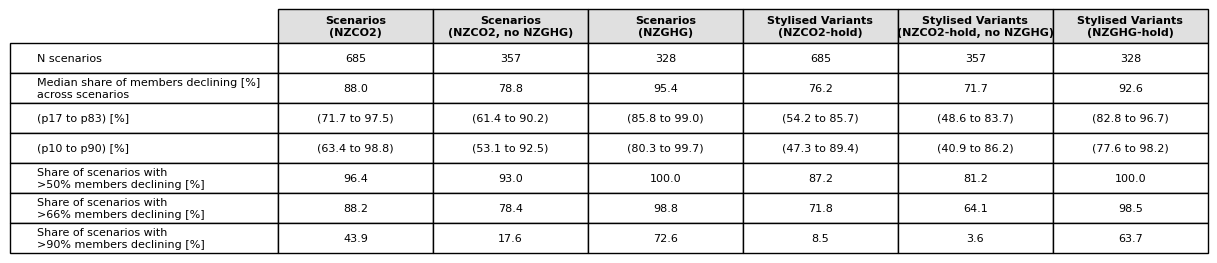

In [129]:
# Plot
fig, ax = plt.subplots(figsize=(12, len(decline_summary_table) * 0.3 + 0.1))
ax.axis("off")
table = ax.table(
    cellText=decline_summary_table.values,
    colLabels=decline_summary_table.columns,
    rowLabels=list(decline_summary_table.index),
    loc="center",
    cellLoc="center",
    colLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.8)

header_height = 0.2
for col_idx in range(len(decline_summary_table.columns)):
    table[0, col_idx].set_height(header_height)
    table[0, col_idx].get_text().set_fontweight("bold")
    table[0, col_idx].set_facecolor("#e0e0e0")

plt.show()
fig.savefig(PLOT_FOLDER / "501_decline_prob_table.png", bbox_inches="tight", dpi=300)
plt.close(fig)

In [131]:
all_df_extended.to_csv(OUTPUT_FOLDER / f"500b_component_metrics_extended_{MANIFEST_ID}.csv")

## Table 2 magnitude of GSAT decline

In [139]:
## Table 2

def calculate_scenario_stats(df, warming_column):
    """
    Calculate per-scenario statistics for delta_warming.
    
    Returns DataFrame with median, 34-67 percentile, and 5-95 percentile per scenario.
    """
    stats = df.groupby(["model", "scenario", "scenario_group"]).agg(
        n_ensemble=pd.NamedAgg(column="run_id", aggfunc="count"),
        median=pd.NamedAgg(column=warming_column, aggfunc="median"),
        p5=pd.NamedAgg(column=warming_column, aggfunc=lambda x: np.percentile(x, 5)),
        p10=pd.NamedAgg(column=warming_column, aggfunc=lambda x: np.percentile(x, 10)),
        p17=pd.NamedAgg(column=warming_column, aggfunc=lambda x: np.percentile(x, 17)),
        p34=pd.NamedAgg(column=warming_column, aggfunc=lambda x: np.percentile(x, 34)),
        p67=pd.NamedAgg(column=warming_column, aggfunc=lambda x: np.percentile(x, 67)),
        p83=pd.NamedAgg(column=warming_column, aggfunc=lambda x: np.percentile(x, 83)),
        p90=pd.NamedAgg(column=warming_column, aggfunc=lambda x: np.percentile(x, 90)),
        p95=pd.NamedAgg(column=warming_column, aggfunc=lambda x: np.percentile(x, 95)),
    ).reset_index()
    return stats


def calculate_group_summary(scenario_stats):
    """
    Calculate summary statistics across all scenarios in each scenario_group.

    Returns DataFrame with:
    - n_scenarios
    - median of medians
    - quantiles of scenario-level quantiles
    """

    group_summary = scenario_stats.groupby("scenario_group").apply(
        lambda df: pd.Series({
            "n_scenarios": df[["model", "scenario"]].drop_duplicates().shape[0],
            "median_of_medians": df["median"].median(),
            "p34_of_p34": df["p34"].quantile(0.34),
            "p67_of_p67": df["p67"].quantile(0.67),
            "p83_of_p83": df["p83"].quantile(0.83),
            "p5_of_p5": df["p5"].quantile(0.05),
            "p10_of_p10": df["p10"].quantile(0.1),
            "p17_of_p17": df["p17"].quantile(0.17),
            "p95_of_p95": df["p95"].quantile(0.95),
            "p90_of_p90": df["p90"].quantile(0.9),
        })
    ).reset_index()

    return group_summary

In [140]:
# Per-scenario statistics
scenario_stats = calculate_scenario_stats(all_df_extended, "GSAT|ANTHROPOGENIC|delta_netzero_co2")

# Group summary
scenarios_summary = calculate_group_summary(scenario_stats)

/var/folders/y4/5qztk4vn4fq27tgyj0wzy83m0000gn/T/ipykernel_27336/1464101790.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_summary = scenario_stats.groupby("scenario_group").apply(


In [141]:
groups = ["Scenarios (NZCO2)", "Scenarios (NZCO2, no NZGHG)", "Scenarios (NZGHG)", 
          "Stylised Variants (NZCO2-hold)", "Stylised Variants (NZCO2-hold, no NZGHG)", "Stylised Variants (NZGHG-hold)"]

def format_cell(row):
    """Format as median with ranges underneath."""
    if row is None:
        return ["—", "", "", "" , ""]
    return [
        f"{row['median_of_medians']:.2f}",
        f"({row['p34_of_p34']:.2f} to {row['p67_of_p67']:.2f})",
        f"({row['p17_of_p17']:.2f} to {row['p83_of_p83']:.2f})",
        f"({row['p10_of_p10']:.2f} to {row['p90_of_p90']:.2f})",
        f"({row['p5_of_p5']:.2f} to {row['p95_of_p95']:.2f})"
    ]

# Index scenarios_summary by scenario_group for easy lookup
group_summaries = scenarios_summary.set_index("scenario_group")

rows = []
for stat_label, val_idx in [
    ("Median of medians", 0),
    ("(p34 to p67)", 1),
    ("(p17 to p83)", 2),
    ("(p10 to p90)", 3),
    ("(p05 to p95)", 4),
]:
    row = {"Statistic": stat_label}
    for grp in groups:
        if grp in group_summaries.index:
            vals = format_cell(group_summaries.loc[grp])
        else:
            vals = ["—", "", "", "", ""]
        row[grp] = vals[val_idx]
    rows.append(row)

summary_table = pd.DataFrame(rows).set_index("Statistic")

# Scenario counts
counts = {
    grp: int(group_summaries.loc[grp, "n_scenarios"]) if grp in group_summaries.index else 0
    for grp in groups
}

print("Delta Warming (NZCO2 year to 2100) [°C]")
print("Scenario counts: " + ", ".join(f"{grp} (n={counts[grp]})" for grp in groups))
print()

summary_table.columns = summary_table.columns.map(rename_map)

Delta Warming (NZCO2 year to 2100) [°C]
Scenario counts: Scenarios (NZCO2) (n=685), Scenarios (NZCO2, no NZGHG) (n=357), Scenarios (NZGHG) (n=328), Stylised Variants (NZCO2-hold) (n=685), Stylised Variants (NZCO2-hold, no NZGHG) (n=357), Stylised Variants (NZGHG-hold) (n=328)



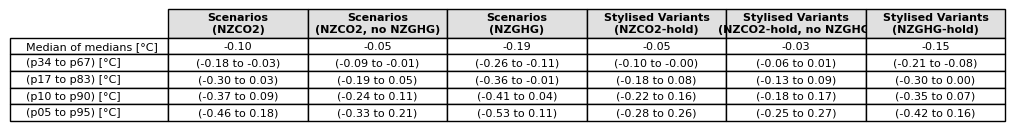

In [142]:
fig, ax = plt.subplots(figsize=(9, len(summary_table) * 0.2))
ax.axis("off")

table = ax.table(
    cellText=summary_table.values,
    colLabels=summary_table.columns,
    rowLabels=[f"{col} [°C]" for col in summary_table.index],
    loc="center",
    cellLoc="center",  # centers cell contents
    colLoc="center",   # centers column headers
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1)

header_height = 0.37  # adjust to taste
for col_idx in range(len(summary_table.columns)):
    table[0, col_idx].set_height(header_height)
    table[0, col_idx].get_text().set_fontweight("bold")
    table[0, col_idx].set_facecolor("#e0e0e0")
    
# Bold column headers (row index 0)
for col_idx in range(len(summary_table.columns)):
    table[0, col_idx].get_text().set_fontweight("bold")
    table[0, col_idx].set_facecolor("#e0e0e0")  # light grey background

plt.show()
#fig.savefig(PLOT_FOLDER / "502_decline_stats_nzco2_table.png", bbox_inches="tight", dpi=300)
#plt.close(fig)

## combined Table

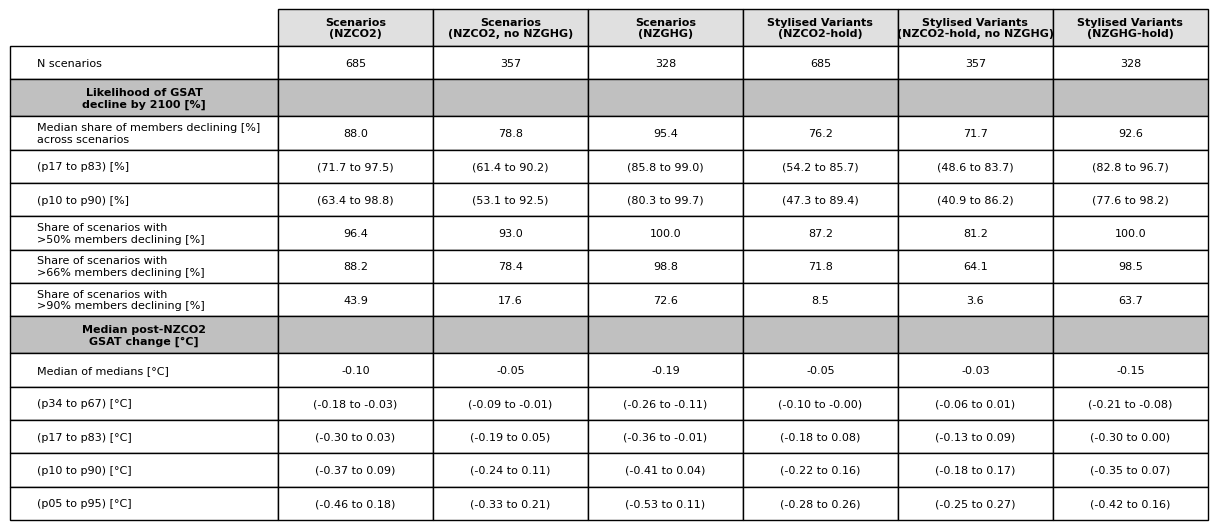

In [149]:
def make_section_header(label, n_cols):
    """Create a single-row DataFrame to use as a section header."""
    return pd.DataFrame(
        [[label] + [""] * (n_cols - 1)],
        columns=range(n_cols)
    )

# Align both tables — they should have the same columns
assert list(decline_summary_table.columns) == list(summary_table.columns)
cols = decline_summary_table.columns
n_cols = len(cols)
n_rows = len(rows)

# Separate N scenarios row from the rest of decline_summary_table
n_scenarios_row = decline_summary_table.loc[["N scenarios"]]
decline_body = decline_summary_table.drop(index="N scenarios")

section1_label = "Likelihood of GSAT\ndecline by 2100 [%]"
section2_label = "Median post-NZCO2\nGSAT change [°C]"

row_labels = (
    list(n_scenarios_row.index) +               # N scenarios row at top
    [section1_label] +                          # section 1 header
    list(decline_body.index) +                  # rest of decline table
    [section2_label] +                          # section 2 header
    [f"{idx} [°C]" for idx in summary_table.index]
)

cell_rows = (
    n_scenarios_row.values.tolist() +           # N scenarios row
    [[""] * n_cols] +                           # section 1 header row
    decline_body.values.tolist() +
    [[""] * n_cols] +                           # section 2 header row
    summary_table.values.tolist()
)

# Section header row indices (1-indexed for table, after col headers)
n_top_rows = len(n_scenarios_row)  # = 1

section_rows = [
    n_top_rows + 1,                          # section 1 header (row 2)
    n_top_rows + 1 + len(decline_body) + 1,  # section 2 header
]

fig, ax = plt.subplots(figsize=(12, n_rows * 0.28 + 1))
ax.axis("off")

table = ax.table(
    cellText=cell_rows,
    colLabels=list(cols),
    rowLabels=row_labels,
    loc="center",
    cellLoc="center",
    colLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 2)

# Style column headers (row 0)
header_height = 0.2
for col_idx in range(n_cols):
    table[0, col_idx].set_height(header_height)
    table[0, col_idx].get_text().set_fontweight("bold")
    table[0, col_idx].set_facecolor("#e0e0e0")

# Identify section header rows (1-indexed because row 0 is col headers)
section_rows = [2, 1 + len(decline_summary_table) + 1]  # row indices in table
        
for row_idx in section_rows:
    for col_idx in range(n_cols):
        table[row_idx, col_idx].set_height(header_height)
    table[row_idx, -1].set_height(header_height)  # row label cell
    # Style the row label cell (-1 index = row label column)
    table[row_idx, -1].get_text().set_fontweight("bold")
    table[row_idx, -1].set_facecolor("#c0c0c0")
    table[row_idx, -1].get_text().set_ha("center")
    # Style the data cells (span visually by making them light grey too)
    for col_idx in range(n_cols):
        table[row_idx, col_idx].set_facecolor("#c0c0c0")
        table[row_idx, col_idx].get_text().set_fontweight("bold")


plt.savefig(PLOT_FOLDER / "601_combined_summary_table_new.png", dpi=300, bbox_inches="tight")
plt.show()

## Supplementary plot on peak vs. NZCO2 timing

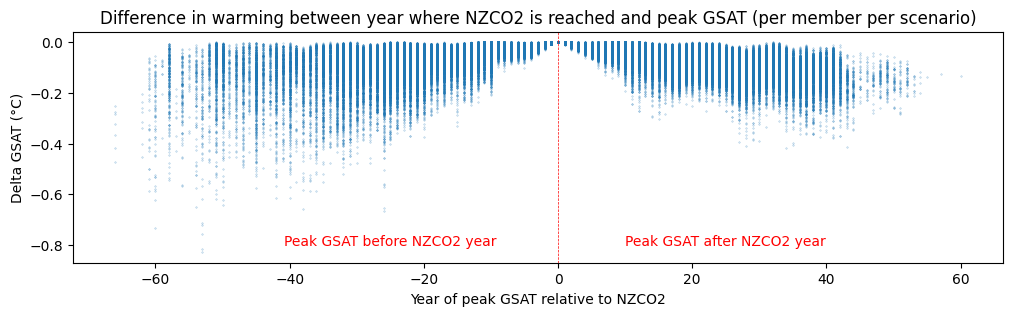

In [219]:
fig, ax = plt.subplots(figsize=(12, 3))

subset = all_df_extended[all_df_extended["scenario_group"]=="Scenarios (NZCO2)"]

x = subset["year_netzero_co2"] - subset["peak_year"]
y = subset["GSAT|ANTHROPOGENIC|netzero_co2"] - subset["GSAT|ANTHROPOGENIC|peak"]

ax.scatter(x, y, marker='x', s=0.8, alpha=.2)
ax.axvline(x=0, linestyle='--', c='red', linewidth=0.5)

# Position text near the top of the plot
y_text = -0.8

ax.text(
    -25,  # halfway between xmin and 0
    y_text,
    "Peak GSAT before NZCO2 year",
    ha="center",
    c="red"
)

ax.text(
    25,     # halfway between 0 and xmax
    y_text,
    "Peak GSAT after NZCO2 year",
    ha="center",
    c="red"
)

ax.set_title("Difference in warming between year where NZCO2 is reached and peak GSAT (per member per scenario)")
ax.set_xlabel("Year of peak GSAT relative to NZCO2")
ax.set_ylabel("Delta GSAT (°C)")

fig.savefig(PLOT_FOLDER / "501_peak_v_nzco2_timing.png", bbox_inches="tight", dpi=300)
    
plt.show()


# the delta is obviously negative or zero by definition, since otherwise the two years coincide

## Detailed Results by Group